# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

WHO: The audience is a decision-maker such as a Budget Committee or VP of Operations who has the authority to approve additional staffing. The presenter is an IT manager acting as the subject-matter expert and using data to explain the operational situation.
 
WHAT: The goal is to persuade the decision-makers to approve hiring two full-time employees to replace staff who left. The audience should clearly understand that the current team cannot keep up with the workload and that additional staffing is necessary to maintain service levels.

HOW: The evidence comes from monthly ticket volume data over the past year. A line graph comparing “Ticket Volume Received” and “Ticket Volume Processed” highlights the growing gap after two employees left in May. Visual emphasis such as color or annotations can be used to draw attention to the recent months where the backlog becomes most noticeable.

# 3. Homework - work with your own data

In [1]:
pip install pandas



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

/home/codespace/.python/current/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 66.0M/66.0M [00:01<00:00, 43.7MB/s]

Extracting files...


Path to dataset files: /home/codespace/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


In [4]:
import os

file_path = os.path.join(path, "creditcard.csv")
fraud_df = pd.read_csv(file_path)

In [5]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
fraud_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
duplicate_count = fraud_df.duplicated().sum()
duplicate_count


np.int64(1081)

In [8]:
fraud_df = fraud_df.drop_duplicates()
fraud_df.duplicated().sum()


np.int64(0)

In [9]:
summary_stats = pd.DataFrame({
    "Mean": fraud_df.mean(),
    "Median": fraud_df.median(),
    "Mode": fraud_df.mode().iloc[0]
})

summary_stats

,Mean,Median,Mode
Time,94811.077600,84692.500000,3767.000000
V1,0.005917,0.020384,1.245674
V2,-0.004135,0.063949,-0.326668
V3,0.001613,0.179963,-2.752041
V4,-0.002966,-0.022248,-0.842316
V5,0.001828,-0.053468,-0.562777
V6,-0.001139,-0.275168,-1.011073
V7,0.001801,0.040859,-0.432126
V8,-0.000854,0.021898,-0.160211
V9,-0.001596,-0.052596,0.170362


In [10]:
fraud_df.isnull().sum().sum()

np.int64(0)

In [11]:
# Check for negative amounts 
(fraud_df["Amount"] < 0).sum()

# Check class values
fraud_df["Class"].unique()

# Check time range
fraud_df["Time"].min(), fraud_df["Time"].max()

# General numeric range
fraud_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


The summary statistics indicate that all variables contain complete data with no missing values. The PCA-transformed features (V1–V28) have means close to zero and similar standard deviations, confirming proper normalization. The Time variable shows a valid sequential range over approximately two days. Transaction amounts are non-negative, and class labels are valid (0 and 1). While some features exhibit extreme values, these reflect valid PCA projections rather than data inconsistencies. Overall, the dataset is clean and suitable for modeling.

Additionally, the dataset contains only numerical variables, including PCA-transformed features and a binary class label. Therefore, no categorical encoding (e.g., one-hot encoding) is required.

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

Dataset Analysis Summary

The dataset was summarized using the info() and describe() functions, which confirmed that all variables contain 284,807 observations with no missing values. All features are numerical, and the PCA-transformed variables have means close to zero and consistent standard deviations, indicating proper normalization.

A duplicate check using duplicated() revealed 1,081 duplicate rows. These duplicates were removed to ensure data integrity before further analysis.

The mean, median, and mode were calculated for each column. Most PCA features have means near zero as a result of dimensionality reduction, while the Amount variable shows right-skewness, with a mean greater than the median, reflecting typical transaction behavior.

A missing value analysis using isnull() confirmed that there are no null or missing entries. Therefore, no imputation or row removal was necessary.

Further validation checks found no inconsistent data. Transaction amounts are non-negative, class labels are valid (0 and 1), and time values fall within an expected sequential range. Extreme values observed in some features are consistent with PCA projections and do not represent errors.

Finally, the dataset contains no categorical variables. All features are numeric, including the binary target variable, so no encoding methods such as one-hot encoding were required.

Exploratory Data Analysis Conclusion

The dataset is usable and well-suited for machine learning modeling. All variables are complete with no missing values, and no structural or formatting inconsistencies were identified. Therefore, no major data corrections or modifications are required prior to modeling.

However, there is significant class imbalance in the dataset. Fraudulent transactions account for only 0.172% of the total observations, meaning the majority class (legitimate transactions) heavily outweighs the minority class. This imbalance must be addressed during modeling through appropriate evaluation metrics (such as precision-recall and AUPRC) and potentially through techniques such as class weighting or resampling.

Overall, the dataset is clean, reliable, and ready for predictive modeling, with the primary challenge being the extreme class imbalance.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

(-0.5, 12.5)

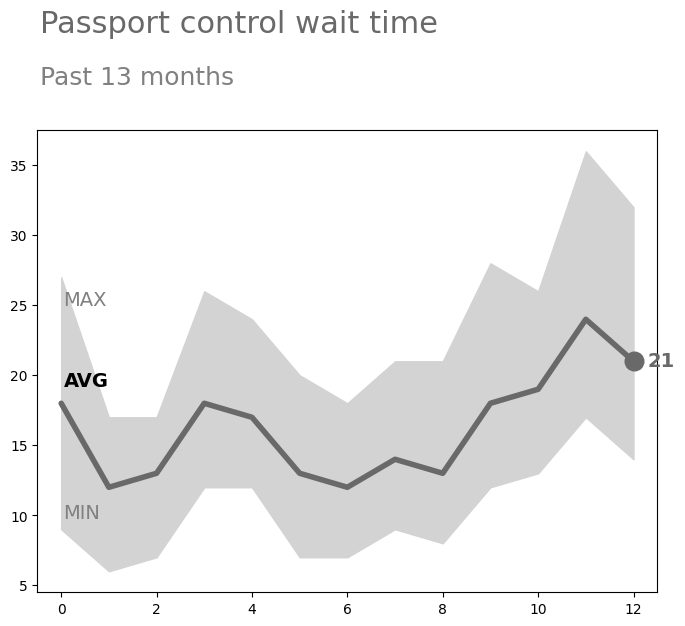

In [12]:
import matplotlib.pyplot as plt
import numpy as np

months = ["Sep", "Oct", "Nov", "Dec", "Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep"]
x = np.arange(len(months))

avg = np.array([18, 12, 13, 18, 17, 13, 12, 14, 13, 18, 19, 24, 21])
min_vals = np.array([9, 6, 7, 12, 12, 7, 7, 9, 8, 12, 13, 17, 14])
max_vals = np.array([27, 17, 17, 26, 24, 20, 18, 21, 21, 28, 26, 36, 32])

fig, ax = plt.subplots(figsize=(8, 6))

# shaded min-max band
ax.fill_between(x, min_vals, max_vals, color="lightgray", alpha=1.0)

# average line
ax.plot(x, avg, color="dimgray", linewidth=4, solid_capstyle="round")

# emphasize last point
ax.scatter(x[-1], avg[-1], s=180, color="dimgray", zorder=5)
ax.text(x[-1] + 0.3, avg[-1], "21", va="center", fontsize=14, fontweight="bold", color="dimgray")

# labels inside plot
ax.text(0.05, max_vals[0] - 2, "MAX", color="gray", fontsize=14)
ax.text(0.05, avg[0] + 1.2, "AVG", color="black", fontsize=14, fontweight="bold")
ax.text(0.05, min_vals[0] + 0.8, "MIN", color="gray", fontsize=14)

# title + subtitle
ax.text(-0.45, 44.5, "Passport control wait time", fontsize=22, color="dimgray")
ax.text(-0.45, 40.8, "Past 13 months", fontsize=18, color="gray")

# axes
ax.set_xlim(-0.5, len(months) - 0.5)
